In [71]:
%matplotlib widget

In [72]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from g4beam import *
from scan import *
from scipy.optimize import differential_evolution
from matplotlib.cm import viridis
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import re
import sys
from pathlib import Path
from matplotlib import cm
import numpy as np
import pandas as pd
from tqdm import *
import pickle
import itertools
import os
from tabulate import tabulate
import tempfile
import glob
import json
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [73]:
# Make Sure g4bl is here
import os
os.environ["PATH"] += os.pathsep + "/home/incik/G4beamline-3.08/bin"
import shutil
print(shutil.which("g4bl"))

/home/incik/G4beamline-3.08/bin/g4bl


## Creating a Single Run with Manually Specifed Parameters

### What Daniel Fu's Wedge Outputs
Note that we will not be using this file as input as we have the wedge inside the g4bl file. "particles_before.txt" is the file input to the g4bl files.

In [ ]:
# Load data POST WEDGE as a Dataframe so that you can use Daniel Fu's functions
filename = "out_1760039204_1614938.txt"

# Skip the first two header lines that start with '#'
with open(filename) as f:
    # Read until the line containing column names
    for line in f:
        if line.startswith("#x "):
            columns = line.strip().lstrip("#").split()
            break

# Now load the data into a DataFrame
df = pd.read_csv(filename, comment="#", sep='\s+', names=columns)

x_params, y_params, z_emit = calc_all_params(df) # _params are tuples of the form (emittance, beta, gamma, alpha, D, D')
D_dict = {"D_x": x_params[4], "D'_x": x_params[5], "D_y": y_params[4], "D'_y": y_params[5]}
print(D_dict)
cost = D_dict["D_x"]**2 + D_dict["D'_x"]**2 + D_dict["D_y"]**2 + D_dict["D'_y"]**2 
print(cost)
print(r"Epsilon_z: "+str(z_emit))

In [ ]:
# Checking before and after the wedge codes:
# Load data POST WEDGE as a Dataframe so that you can use Daniel Fu's functions
filename = ["vd_start_dispsup.txt", "particles_before.txt"]

for file in filename:
    # Skip the first two header lines that start with '#'
    with open(file) as f:
        # Read until the line containing column names
        for line in f:
            if line.startswith("#x "):
                columns = line.strip().lstrip("#").split()
                break

    # Now load the data into a DataFrame
    df = pd.read_csv(file, comment="#", sep='\s+', names=columns)

    x_params, y_params, z_emit = calc_all_params(df) # _params are tuples of the form (emittance, beta, gamma, alpha, D, D')
    D_dict = {"D_x": x_params[4], "D'_x": x_params[5], "D_y": y_params[4], "D'_y": y_params[5]}
    print(D_dict)
    cost = D_dict["D_x"]**2 + D_dict["D'_x"]**2 + D_dict["D_y"]**2 + D_dict["D'_y"]**2 
    print(cost)
    print(r"Epsilon_z: "+str(z_emit))

In [ ]:
# Replace with your beam file
filename = "out_1760039204_1614938.txt"

# Load data assuming BLTrackFile columns: x y z px py pz t particleID ...
# Adjust columns if your file is different
data = np.loadtxt(filename, comments="#")

# Extract px, py, pz
px = data[:, 3]
py = data[:, 4]
pz = data[:, 5]

# Compute average momentum components
px_ref = np.mean(px)
py_ref = np.mean(py)
pz_ref = np.mean(pz)

# Compute average total momentum magnitude
p_ref = np.sqrt(px_ref**2 + py_ref**2 + pz_ref**2)

print(f"Reference particle momentum components: px={px_ref:.6f}, py={py_ref:.6f}, pz={pz_ref:.6f}")
print(f"Reference particle total momentum: p = {p_ref:.6f}")

In [ ]:
desired_p = np.array([-0.204087, -0.204087, 88.961842])  # px, py, pz in MeV/c

data = np.loadtxt("out_1760039204_1614938.txt")
momenta = data[:, 3:6]  # px, py, pz

# Find the particle index closest to desired momentum
dist = np.linalg.norm(momenta - desired_p, axis=1)
ref_index = np.argmin(dist)

print("Use this index in referenceParticle:", ref_index)


### Manually input parameters to create a g4bl file from template
The g4bl files specifically take particles_before.txt as input, as specified inside the .g4bl

In [ ]:
import re
# Importing result from a DE optimizer in a specific format as below:
"""
Best result:
  B1_field             =     0.2101
  B1_width             =   122.8026
  B1_height            =   265.3664
  B1_length            =    83.8629
  Q1_gradient          =    -1.2517
  Q1_length            =   297.0612
  radius_q             =    63.9380
  Q1_z                 =   118.5929
  thickness            =   410.4403
  Q2_gradient          =    -0.1835
  Q2_width             =   174.4412
  Q2_height            =   125.0376
  Q2_length            =   183.4535
  Drift1_width         =   173.3462
  Drift1_height        =   243.1225
  Drift1_length        =   139.7656
  Drift2_width         =   191.6180
  Drift2_height        =   121.9246
  Drift2_length        =    86.8190
Final cost = 3.327e+10

"""
def parse_best_result(text):
    # Regex: captures variable name and numeric value (supports +/-, decimals, exponents)
    pattern = r"([A-Za-z0-9_]+)\s*=\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)"
    matches = re.findall(pattern, text)

    # Convert to dictionary
    result_dict = {k: float(v) for k, v in matches}

    # Optional: turn into NumPy array (just the values)
    keys = list(result_dict.keys())
    values = np.array([result_dict[k] for k in keys])

    # Print them as a Python-style array
    print(", ".join(str(v) for v in values[:-1]))

    return result_dict, keys, values
text = input("Paste the best result from optimization")
result_dict, keys, xvec = parse_best_result(text)

## Start Running One File

In [103]:
# ---------------- USER CONFIG ----------------
G4BEAMLINE_CMD = "g4bl"
TEMPLATE_FILE = "G4_FinalCooling_dispsup_Template.g4bl"
OUTPUT_DIR = "dispsup_runs"
VD_FILENAME = "vd_dispsup.txt"   # virtual detector writes this file (ascii)
N_PARTICLES = 5000             # increase for lower noise
G4BLFILE = f"G4_FinalCooling_dispsup_Template_run.g4bl"
G4BLOUTPUT =f"/home/incik/Cooling_4D/DispSupOpts/{VD_FILENAME}"
E0 = 1e4                       # beam energy (GeV) - for a muon collider

# Let's first take in the parameters that the wedge has

def read_g4bl_params(filename):
    """
    Reads 'param' definitions from a .g4bl file and returns a dict of parameter names and values.
    """
    params = {}
    pattern = re.compile(r"param\s+(?:-unset\s+)?(\w+)=([^\s#]+)")
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if not line.startswith("param"):
                continue
            m = pattern.search(line)
            if m:
                key, val = m.groups()
                try:
                    params[key] = float(eval(val, {"__builtins__": None, "pi": math.pi}))
                except Exception:
                    params[key] = val  # keep as string if not numeric
    return params


def compute_wedge_geometry(params):
    """
    Given parameters like absLEN3, abshgt, abswidth, abshalfangle3, compute geometry info.
    """
    W = params.get("absLEN3")
    H = params.get("abshgt")
    L = params.get("abswidth")
    half_angle_deg = params.get("abshalfangle3")
    offset = params.get("absoffset3", 0)

    if L and half_angle_deg:
        half_angle_rad = math.radians(half_angle_deg)
        L_centerline = W / math.sin(half_angle_rad)

    return {
        "Length_Wedge": L,
        "Height_Base": H,
        "Width_Base": W,
        "Half-angle": half_angle_deg,
        "Centerline_Coords": L_centerline,
        "Offset": offset
    }


if len(sys.argv) < 2:
    print("Usage: python read_wedge_params.py <file.g4bl>")
    sys.exit(1)

file_path = "G4_FinalCooling_dispsup_Template.g4bl"
params = read_g4bl_params(file_path)
geom = compute_wedge_geometry(params)

print("Parameters found:")
for k, v in params.items():
    print(f"  {k:15s} = {v}")

print("Derived geometry:")
for k, v in geom.items():
    print(f"  {k:20s}: {v}")

Parameters found:
  zbegin          = 0.0
  steppingFormat  = N,GLOBAL,CL,STEP,VOL,PROCESS,P,KE,POLAR,B
  fieldVoxels     = 400,400,400
  maxStep         = 0.5
  minRangeCut     = 1.0
  nparticles      = {N_PARTICLES}
  beamfile        = particles_before_new.txt
  pi              = 3.141592654
  degrad          = $pi/180
  abshgt          = 2.079108542938554
  abswidth        = 100.0
  absLEN3         = 4.944980996971603
  abshalfangle3   = 51.32442402932793
  absoffset3      = 2.4724904984858016
  wedge_z         = 0.5*$absLEN3
  VDRad           = 60.0
  wedgeAxis       = 0.0
  noWedge         = 0.0
Derived geometry:
  Length_Wedge        : 100.0
  Height_Base         : 2.079108542938554
  Width_Base          : 4.944980996971603
  Half-angle          : 51.32442402932793
  Centerline_Coords   : 6.334060274369019
  Offset              : 2.4724904984858016


In [104]:
geom["Length_Wedge"]

100.0

In [371]:
# {B1_field}, {B1_width}, {B1_height}, {B1_length}, {B1_z}, {Q1_gradient}, {Q1_length}, {radius_q}
# {B2_field}, {B2_width}, {B2_height}, {B2_length}
# {Drift1_width}, {Drift1_height}, {Drift1_length}, 
# {Drift2_width}, {Drift2_height}, {Drift2_length}

var_names = ["N_PARTICLES", "B1_field", "B1_width", "B1_height", "B1_length", 
    "Q1_gradient", "Q1_length", "radius_q", "thickness",
    "Q2_gradient", "Q2_length",
    "Drift1_width", "Drift1_height", "Drift1_length",  
    "Drift2_width", "Drift2_height","Drift2_length", "VD_FILENAME"]
    
# xvec = np.array([int(N_PARTICLES), 0.2101, 122.8026, 265.3664, 83.8629, -1.2517, 297.0612, 63.938, 118.5929, 410.4403, -0.1835,  174.4412, 125.0376, 183.4535, 173.3462, 243.1225, 139.7656, 191.618, 121.9246, 86.819, VD_FILENAME])
# BEST: xvec = np.array([int(N_PARTICLES), 1.5, 100, 100, 30, -5.761867, 30, 0.086115, 0.05, -6.188691, 25, 10, 10, 10, 10, 10, 10, VD_FILENAME])
# xvec = np.array([int(N_PARTICLES), 0.05, geom["Length_Wedge"], geom["Length_Wedge"], 100, 1, 100, 50, 10, -0.2, 100, geom["Length_Wedge"], geom["Length_Wedge"], 100, geom["Length_Wedge"], geom["Length_Wedge"], 100, VD_FILENAME])
xvec = np.array([int(N_PARTICLES), -0.35, geom["Length_Wedge"], geom["Length_Wedge"], 120, 
                0.05, 30, 50, 10, 
                -0.05, 30, 
                geom["Length_Wedge"], geom["Length_Wedge"], 10, 
                geom["Length_Wedge"], geom["Length_Wedge"], 10, VD_FILENAME])
GAP = 0.1  # in mm (can be up to 1.0 safely)
A_GAP = 5 # mm
calcparams = {name: val for name, val in zip(var_names, xvec)}

L_Q1 = float(calcparams["Q1_length"])
L_D1 = float(calcparams["Drift1_length"])
L_Q2 = float(calcparams["Q2_length"])
L_D2 = float(calcparams["Drift2_length"])
L_B1 = float(calcparams["B1_length"])

wedge_end = geom["Centerline_Coords"]
Q1_z      = geom["Centerline_Coords"] + (L_Q1/2)
Drift1_z = Q1_z + (L_Q1/2) + (L_D1/2) + GAP
Q2_z     = Drift1_z + (L_D1/2) + (L_Q2/2) + GAP
Drift2_z = Q2_z + (L_Q2/2) + (L_D2/2)+ GAP
B1_z     = Drift2_z + (L_D2/2) + (L_B1/2) + GAP
VD_z     = B1_z + (L_B1/2) + 10.0 + GAP
nZ = int(VD_z)

Q1_end = Q1_z + (L_Q1/2)
D1_end = Drift1_z + (L_D1/2)
Q2_end = Q2_z + (L_Q2/2)
D2_end = Drift2_z + (L_D2/2)
B1_end = B1_z + (L_B1/2)

add_params = {"wedge_end": wedge_end, "Q1_z": Q1_z, "Drift1_z": Drift1_z, "Q2_z": Q2_z, "Drift2_z":Drift2_z, "B1_z": B1_z,"VD_z": VD_z, 
        "B1_end": B1_end, "Q2_end": Q2_end,  "D1_end": D1_end, "Q1_end": Q1_end,  "D2_end": D2_end, "N_PARTICLES": N_PARTICLES, "nZ": nZ,
        "VD_FILENAME": VD_FILENAME}

calcparams.update(add_params)

for k, v in calcparams.items():
    if k == "N_PARTICLES" or k == "VD_FILENAME":
        continue
    else:
        calcparams[k] = float(v)

os.makedirs(OUTPUT_DIR, exist_ok=True)

### Creating the Run File

In [372]:
# Write values to the prepared G4BL template
def write_input_from_template(template_path, out_path, replacements):
    with open(template_path, 'r') as f:
        txt = f.read()
    try:
        txt = txt.format(**replacements)
    except KeyError as e:
        raise RuntimeError(f"Template substitution failed; missing placeholder: {e}")
    with open(out_path, 'w') as f:
        f.write(txt)

# How to Use?
print(calcparams)
write_input_from_template(TEMPLATE_FILE, G4BLFILE, calcparams)

{'N_PARTICLES': 5000, 'B1_field': -0.35, 'B1_width': 100.0, 'B1_height': 100.0, 'B1_length': 120.0, 'Q1_gradient': 0.05, 'Q1_length': 30.0, 'radius_q': 50.0, 'thickness': 10.0, 'Q2_gradient': -0.05, 'Q2_length': 30.0, 'Drift1_width': 100.0, 'Drift1_height': 100.0, 'Drift1_length': 10.0, 'Drift2_width': 100.0, 'Drift2_height': 100.0, 'Drift2_length': 10.0, 'VD_FILENAME': 'vd_dispsup.txt', 'wedge_end': 6.334060274369019, 'Q1_z': 21.33406027436902, 'Drift1_z': 41.434060274369024, 'Q2_z': 61.534060274369025, 'Drift2_z': 81.63406027436902, 'B1_z': 146.734060274369, 'VD_z': 216.834060274369, 'B1_end': 206.734060274369, 'Q2_end': 76.53406027436903, 'D1_end': 46.434060274369024, 'Q1_end': 36.33406027436902, 'D2_end': 86.63406027436902, 'nZ': 216.0}


In [373]:
# Run g4bl and get the Output file
"""
G4BLFILE = f"G4_FinalCooling_wdc_run_40.0_7.g4bl"
G4BLOUTPUT3 = f"vd_B1_end_achromat_40.0_7.txt"
G4BLOUTPUT2 = f"vd_wedge_end_achromat.txt"
G4BLOUTPUT1= f"vd_start_achromat.txt"
"""
if os.path.exists("field_cell.dat"):
    os.remove("field_cell.dat")
result = subprocess.run(["g4bl", G4BLFILE], capture_output=True, text=True, check=True)
print(result)

CompletedProcess(args=['g4bl', 'G4_FinalCooling_dispsup_Template_run.g4bl'], returncode=0, stdout="G4BL_DIR=/home/incik/G4beamline-3.08\nG4LEDATA=/home/incik/Geant4Data/G4EMLOW8.0\nG4ENSDFSTATEDATA=/home/incik/Geant4Data/G4ENSDFSTATE2.3\nG4PARTICLEXSDATA=/home/incik/Geant4Data/G4PARTICLEXS4.0\nG4LEVELGAMMADATA=/home/incik/Geant4Data/PhotonEvaporation5.7\nG4RADIOACTIVEDATA=/home/incik/Geant4Data/RadioactiveDecay5.6\nG4beamline Process ID 14304\n\n*************************************************************\n g4beamline version: 3.08                        (Aug 11 2022)\n                      Copyright : Tom Roberts, Muons, Inc.\n                        License : Gnu Public License\n                            WWW : http://g4beamline.muonsinc.com\n\n          ################################\n          !!! G4Backtrace is activated !!!\n          ################################\n\n\n**************************************************************\n Geant4 version Name: geant4-11-00-patch-

In [374]:
# Make the results a dataframe and calculate the Courant-Snyder Parameters
df = read_trackfile(G4BLOUTPUT)
x_params, y_params, z_emit = calc_all_params(df)
print(x_params)

(np.float64(0.2819326873014258), np.float64(1.091101942086688), np.float64(26.455793835625737), np.float64(-5.2788225991688975), np.float64(-0.002703420166867007), np.float64(-0.01634118869817949))


In [375]:
z_emit

np.float64(6.34120649325344)

In [376]:
D_dict = {"D_x": x_params[4], "D'_x": x_params[5], "D_y": y_params[4], "D'_y": y_params[5]}
print(D_dict)
cost = D_dict["D_x"]**2 + D_dict["D'_x"]**2 + D_dict["D_y"]**2 + D_dict["D'_y"]**2 
print(cost)
print(r"Epsilon_z: "+str(z_emit))

{'D_x': np.float64(-0.002703420166867007), "D'_x": np.float64(-0.01634118869817949), 'D_y': np.float64(-0.012494782152532441), "D'_y": np.float64(-0.07933068701906255)}
0.006723820412623835
Epsilon_z: 6.34120649325344


'D_dict2 = {"D_x": x_params2[4], "D\'_x": x_params2[5], "D_y": y_params2[4], "D\'_y": y_params2[5]}\nprint(D_dict2)\ncost2 = D_dict2["D_x"]**2 + D_dict2["D\'_x"]**2 + D_dict2["D_y"]**2 + D_dict2["D\'_y"]**2 \nprint(cost2)\nprint(r"Epsilon_z: "+str(z_emit2))\n\nD_dict3 = {"D_x": x_params3[4], "D\'_x": x_params3[5], "D_y": y_params3[4], "D\'_y": y_params3[5]}\nprint(D_dict3)\ncost3 = D_dict3["D_x"]**2 + D_dict3["D\'_x"]**2 + D_dict3["D_y"]**2 + D_dict3["D\'_y"]**2 \nprint(cost3)\nprint(r"Epsilon_z: "+str(z_emit3))'

In [377]:
with open(G4BLOUTPUT) as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)

# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)


4967
99.34


[[ 0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00 -4.74783e-02
   0.00000e+00]
 [ 0.00000e+00  0.00000e+00  1.00000e+00  0.00000e+00 -4.81412e-02
   0.00000e+00]
 [ 0.00000e+00  0.00000e+00  2.00000e+00  0.00000e+00 -4.88099e-02
   0.00000e+00]
 ...
 [ 0.00000e+00  0.00000e+00  2.13000e+02  0.00000e+00 -1.24465e-01
   0.00000e+00]
 [ 0.00000e+00  0.00000e+00  2.14000e+02  0.00000e+00 -1.23048e-01
   0.00000e+00]
 [ 0.00000e+00  0.00000e+00  2.15000e+02  0.00000e+00 -1.21651e-01
   0.00000e+00]]
{'COLORS': 100.0, 'wedge_end': 6.334060274369019, 'B1_field': -0.35, 'B1_width': 100.0, 'B1_height': 100.0, 'B1_length': 120.0, 'B1_z': 146.734060274369, 'Q1_z': 21.33406027436902, 'Q2_z': 61.534060274369025, 'Drift1_z': 41.434060274369024, 'Drift2_z': 81.63406027436902, 'Drift1_length': 10.0, 'Drift2_length': 10.0, 'Q1_gradient': 0.05, 'Q1_length': 30.0, 'radius_q': 50.0, 'thickness': 10.0, 'Q2_gradient': -0.05, 'Q2_length': 30.0}


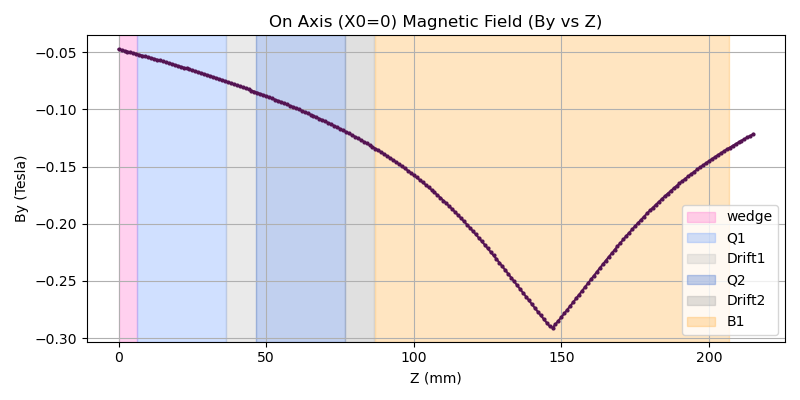

In [378]:
def fieldEvolution():
    """ 
    Evolution of the magnetic field across elements, plotted. 
    
    """
    # Load file, skipping comment lines
    with open("field_cell.dat") as f:
        lines = f.readlines()[4:]
    
    data = np.array([[float(x) for x in line.split()] for line in lines])
    print(data)
    
    # If the file has columns: x y z Bx By Bz
    # then we can extract:
    z = data[:, 2]
    by = data[:, 4]
    
    
    # Draw shaded regions for magnets
    # Read your g4bl file
    with open("G4_FinalCooling_dispsup_Template_run.g4bl") as f:
        text = f.read()

    # Extract magnets (dipoles, quads, drifts, etc.)
    pattern = r"\s*([A-Za-z0-9_]+):\s*([-\d\.]+)"
    entries = dict(re.findall(pattern, text))
    
    # Convert numeric values
    params = {k: float(v) for k, v in entries.items()}
    print(params)
    magnet_colors = {"wedge":  "#FF66CC",
            "Q1":     "#6699FF",   # soft blue
            "Drift1": "#BBBBBB",   # light gray
            "Q2":     "#3366CC",   # deeper blue
            "Drift2": "#999999",   # mid gray
            "B1":     "#FFAA33",   # warm orange
        }

    regions = []
    magnet_order = ["wedge", "Q1", "Drift1", "Q2", "Drift2", "B1"]

    for name in magnet_order:
        z_key = f"{name}_z"
        L_key = f"{name}_length"
        
        if name == "wedge":
            # Wedge uses different parameter names
            if "wedge_end" in params:
                length = params["wedge_end"]
                z1 = 0
                z2 = length
                regions.append((z1, z2, magnet_colors["wedge"], "wedge"))
    
        elif z_key in params and L_key in params:
            center = params[z_key]
            length = params[L_key]
            z1 = center - length / 2
            z2 = center + length / 2
            regions.append((z1, z2, magnet_colors[name], name))
        else:
            print(f"⚠ Missing parameters for {name}, skipping shading.")

    plt.figure(figsize=(8, 4))
    for z1, z2, color, label in regions:
        if z1 is not None and z2 is not None:
            plt.axvspan(z1, z2, color=color, alpha=0.3, label=label)
    
    plt.plot(z, by, '-o', color="#541352FF", markersize=2)
    plt.xlabel("Z (mm)")
    plt.ylabel("By (Tesla)")
    plt.title("On Axis (X0=0) Magnetic Field (By vs Z)")
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.savefig("Bfields.png")

fieldEvolution()

In [379]:
def twissPlot(z_positions, emit_x, emit_y, emit_z, beta_x, beta_y, alpha_x, alpha_y, D_x, Dp_x, D_y, Dp_y, output_folder="./dispsup_plots"):
    
    # -------------------------------------------------------------------
    # CONVERT TO ARRAYS FOR PLOTTING
    # -------------------------------------------------------------------
    z_positions = np.array(z_positions)
    order = np.argsort(z_positions)

    z_positions = z_positions[order]
    emit_x = np.array(emit_x)[order]
    emit_y = np.array(emit_y)[order]
    beta_x = np.array(beta_x)[order]
    beta_y = np.array(beta_y)[order]
    alpha_x = np.array(alpha_x)[order]
    alpha_y = np.array(alpha_y)[order]
    D_x = np.array(D_x)[order]
    Dp_x = np.array(Dp_x)[order]
    D_y = np.array(D_y)[order]
    Dp_y = np.array(Dp_y)[order]
    emit_z = np.array(emit_z)[order]

    # -------------------------------------------------------------------
    # PLOTTING
    # -------------------------------------------------------------------

    def make_plot(yvals, ylabel, title, filename, labels=("x", "y")):
        plt.figure(figsize=(7,5))
        # Draw shaded regions for magnets
        # Read your g4bl file
        with open("G4_FinalCooling_dispsup_Template_run.g4bl") as f:
            text = f.read()

        # Extract magnets (dipoles, quads, drifts, etc.)
        pattern = r"\s*([A-Za-z0-9_]+):\s*([-\d\.]+)"
        entries = dict(re.findall(pattern, text))
        
        # Convert numeric values
        params = {k: float(v) for k, v in entries.items()}
        print(entries.items(), params)
        
        magnet_colors = {"wedge":  "#FF66CC",
            "Q1":     "#6699FF",   # soft blue
            "Drift1": "#BBBBBB",   # light gray
            "Q2":     "#3366CC",   # deeper blue
            "Drift2": "#999999",   # mid gray
            "B1":     "#FFAA33",   # warm orange
        }

        regions = []
        magnet_order = ["wedge", "Q1", "Drift1", "Q2", "Drift2", "B1"]

        for name in magnet_order:
            z_key = f"{name}_z"
            L_key = f"{name}_length"
            
            if name == "wedge":
                # Wedge uses different parameter names
                if "wedge_end" in params:
                    length = params["wedge_end"]
                    z1 = 0
                    z2 = length
                    regions.append((z1, z2, magnet_colors["wedge"], "wedge"))
        
            elif z_key in params and L_key in params:
                center = params[z_key]
                length = params[L_key]
                z1 = center - length / 2
                z2 = center + length / 2
                regions.append((z1, z2, magnet_colors[name], name))
            else:
                print(f"⚠ Missing parameters for {name}, skipping shading.")
           
        for z1, z2, color, label in regions:
            if z1 is not None and z2 is not None:
                plt.axvspan(z1, z2, color=color, alpha=0.3, label=label)
    
        plt.plot(z_positions, yvals[0], 'o-',  color="#541352FF", label=f"{labels[0]}-plane")
        plt.plot(z_positions, yvals[1], 's--',  color="#3A5E8CFF", label=f"{labels[1]}-plane")
        plt.xlabel("z [mm]")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(output_folder, filename))
        plt.close()

    make_plot((emit_x, emit_y), "Emittance [mm·mrad]",
            "Emittance Evolution", "emittance_evolution.png")

    make_plot((beta_x, beta_y), "β-function [m]",
            "Beta Function Evolution", "beta_evolution.png")

    make_plot((alpha_x, alpha_y), "α-function [–]",
            "Alpha Function Evolution", "alpha_evolution.png")

    make_plot((D_x, D_y), "Dispersion D [m]",
            "Dispersion Function", "dispersion_D.png")

    make_plot((Dp_x, Dp_y), "Dispersion Derivative D' [-]",
            "Dispersion Derivative", "dispersion_Dprime.png")

    print(f"All plots saved in '{output_folder}'")


files = ["vd_start_dispsup.txt", "vd_wedge_end_achromat.txt", "vd_Q1_dispsup.txt", "vd_D1_dispsup.txt", "vd_Q2_dispsup.txt", "vd_D2_dispsup.txt", "vd_B1_dispsup.txt"]
z_positions = []
emit_x = []
emit_y = []
emit_z = []
beta_x = []
beta_y= []
alpha_x=[]
alpha_y=[]
D_x=[]
Dp_x=[]
D_y=[]
Dp_y=[]

for i in files:
        df1 = read_trackfile(i)
        z_positions.append(np.mean(df1["z"]))
        x_params1, y_params1, z_emit1 = calc_all_params(df1)
        ex, bx, gx, ax, Dx, Dxp = x_params1
        ey, by, gy, ay, Dy, Dyp = y_params1
        emit_x.append(ex)
        emit_y.append(ey)
        beta_x.append(bx)
        beta_y.append(by)
        alpha_x.append(ax)
        alpha_y.append(ay)
        D_x.append(Dx), Dp_x.append(Dxp), D_y.append(Dy), Dp_y.append(Dyp)
        emit_z.append(z_emit1)

twissPlot(z_positions, emit_x, emit_y, emit_z, beta_x, beta_y, alpha_x, alpha_y, D_x, Dp_x, D_y, Dp_y)

dict_items([('COLORS', '100'), ('wedge_end', '6.334060274369019'), ('B1_field', '-0.35'), ('B1_width', '100.0'), ('B1_height', '100.0'), ('B1_length', '120.0'), ('B1_z', '146.734060274369'), ('Q1_z', '21.33406027436902'), ('Q2_z', '61.534060274369025'), ('Drift1_z', '41.434060274369024'), ('Drift2_z', '81.63406027436902'), ('Drift1_length', '10.0'), ('Drift2_length', '10.0'), ('Q1_gradient', '0.05'), ('Q1_length', '30.0'), ('radius_q', '50.0'), ('thickness', '10.0'), ('Q2_gradient', '-0.05'), ('Q2_length', '30.0')]) {'COLORS': 100.0, 'wedge_end': 6.334060274369019, 'B1_field': -0.35, 'B1_width': 100.0, 'B1_height': 100.0, 'B1_length': 120.0, 'B1_z': 146.734060274369, 'Q1_z': 21.33406027436902, 'Q2_z': 61.534060274369025, 'Drift1_z': 41.434060274369024, 'Drift2_z': 81.63406027436902, 'Drift1_length': 10.0, 'Drift2_length': 10.0, 'Q1_gradient': 0.05, 'Q1_length': 30.0, 'radius_q': 50.0, 'thickness': 10.0, 'Q2_gradient': -0.05, 'Q2_length': 30.0}
dict_items([('COLORS', '100'), ('wedge_end